# Image Metadata Viewer

This notebook loads images from a folder and displays them with their metadata (title and tags) from the MetadataManager.

## 1. Import Required Libraries

Import necessary libraries including os, pathlib, PIL for image handling, and the MetadataManager from phototag.

In [14]:
import os
import re
import sys
import textwrap
from datetime import datetime, timedelta
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from typing import Optional
from dotenv import load_dotenv

# Add the src directory to the path
sys.path.insert(0, str(Path.cwd() / "src"))

from phototag.db import Db
from phototag.phototag import PhotoTag
from phototag.metadata_manager import MetadataManager

## 1. Define display function

Implement the function to display the metadata for images

In [15]:
def display_image_with_metadata(image_path: Path, meta_manager: MetadataManager):
    """Display a single image with its metadata."""
    try:
        # Get metadata from manager
        metadata = meta_manager.get_by_filename(str(image_path))

        # Load and display image
        img = Image.open(image_path)

        # Create figure with image and metadata
        fig = plt.figure(figsize=(12, 6))
        gs = GridSpec(1, 2, width_ratios=[2, 1], figure=fig)

        # Display image
        ax_img = fig.add_subplot(gs[0])
        ax_img.imshow(img)
        ax_img.set_title(image_path.name, fontsize=12, fontweight="bold")
        ax_img.axis("off")

        # Display metadata
        ax_meta = fig.add_subplot(gs[1])
        ax_meta.axis("off")

        meta_text = f"File: {image_path.name}\n\n"
        raw_text = f"{image_path.name}\n"

        if metadata:
            # Wrap long title
            title = metadata.title or "N/A"
            wrapped_title = textwrap.fill(title, width=40)
            meta_text += f"Title: {wrapped_title}\n\n"
            raw_text += f"{title}\n"

            # Wrap and format tags
            if metadata.keywords:
                tags_text = ", ".join(metadata.keywords)
                wrapped_tags = textwrap.fill(f"Tags: {tags_text}", width=40)
                meta_text += f"{wrapped_tags}\n\n"
                raw_text += f"{tags_text}\n"
            else:
                meta_text += "Tags: No tags\n\n"
                raw_text += f"No tags\n"

            # Wrap long description
            description = metadata.description or "N/A"
            wrapped_desc = textwrap.fill(f"Description: {description}", width=40)
            meta_text += wrapped_desc
            raw_text += f"{description}\n"
        else:
            meta_text += "No metadata found in database"

        ax_meta.text(
            0.05,
            0.95,
            meta_text,
            transform=ax_meta.transAxes,
            fontsize=9,
            verticalalignment="top",
            fontfamily="monospace",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.3),
        )

        plt.tight_layout()
        plt.show()
        print(raw_text)

    except Exception as e:
        print(f"Error displaying {image_path.name}: {e}")

## 2. Define Source Folder Parameter

Set the source folder path as a parameter that can be easily modified. Point to the directory containing images to process.

In [16]:
# Load environment variables from ~/.phototag.env
load_dotenv(dotenv_path=Path.home() / ".phototag.env")

# Get configuration from environment variables
URL = os.getenv("PHOTOTAG_URL", "https://server.phototag.ai/api/keywords")
TOKEN = os.getenv("PHOTOTAG_TOKEN", "")
DB_FILE = os.getenv("PHOTOTAG_DB", str(Path.home() / ".phototag_db.json"))

# Validate that token is available
if not TOKEN:
    print(
        "Warning: PHOTOTAG_TOKEN not found in environment. Set it in ~/.phototag.env or as an environment variable."
    )

# Initialize Db and PhotoTag
db = Db(DB_FILE)
phototag = PhotoTag(
    url=URL,
    token=TOKEN,
)

# Create MetadataManager instance
meta_manager = MetadataManager(db, phototag)

print(f"MetadataManager initialized")
print(f"API URL: {URL}")
print(f"Database file: {DB_FILE}")
with db as c:
    print(f"Database record count: {c.len()}")

MetadataManager initialized
API URL: https://server.phototag.ai/api/keywords
Database file: /Users/igor/.phototag_db.json
Database record count: 538


## 4. Load and Display Images with Metadata

Iterate through all image files in the source folder, retrieve existing metadata (title and tags) from MetadataManager for each image, and display the image with its associated metadata.

Source folder: /Users/igor/Pictures/Lightroom Saved Photos
Found 1320 image files
Filtered to 120 images modified in the last 10 days
Database contains 538 image filenames
Filtered to 55 images present in the database
Filtered to 55 images matching regexp: expo-*
Filtered to 10 after limiting to at most 10 images


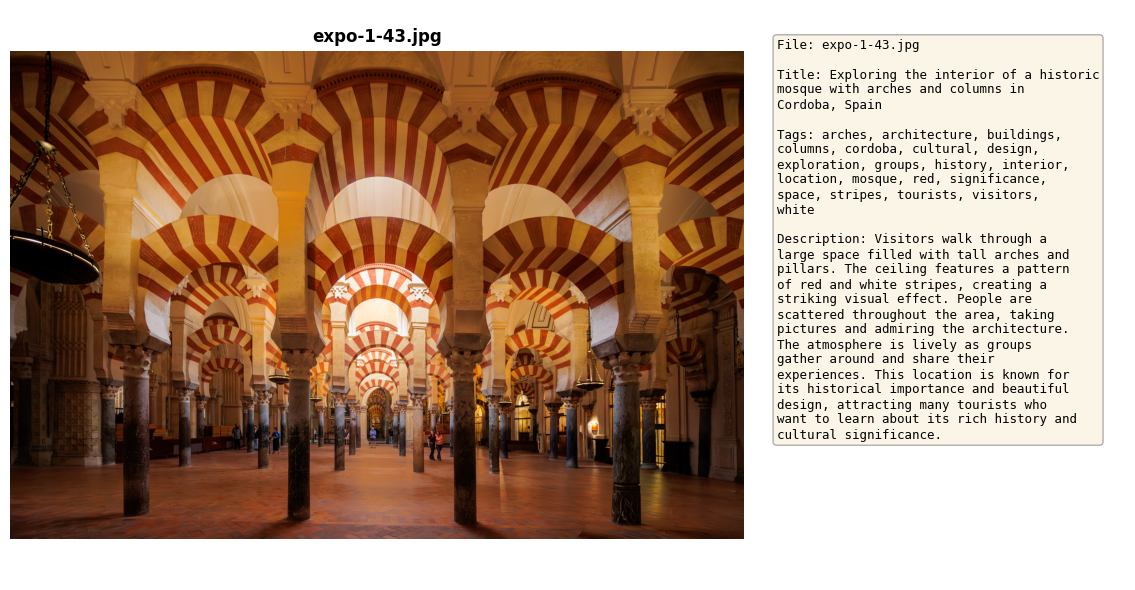

expo-1-43.jpg
Exploring the interior of a historic mosque with arches and columns in Cordoba, Spain
arches, architecture, buildings, columns, cordoba, cultural, design, exploration, groups, history, interior, location, mosque, red, significance, space, stripes, tourists, visitors, white
Visitors walk through a large space filled with tall arches and pillars. The ceiling features a pattern of red and white stripes, creating a striking visual effect. People are scattered throughout the area, taking pictures and admiring the architecture. The atmosphere is lively as groups gather around and share their experiences. This location is known for its historical importance and beautiful design, attracting many tourists who want to learn about its rich history and cultural significance.



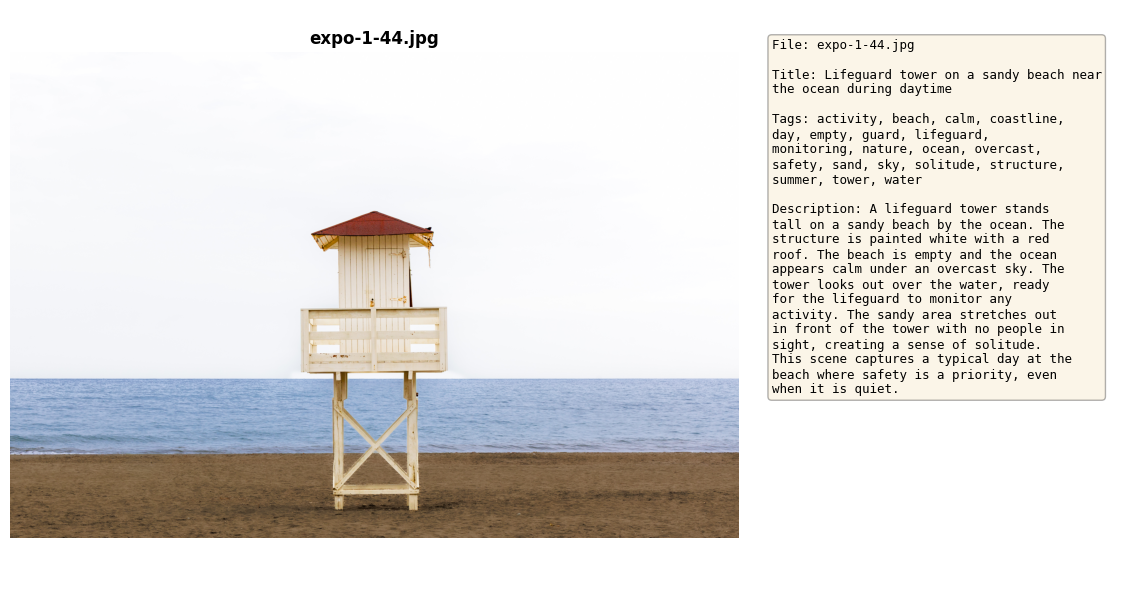

expo-1-44.jpg
Lifeguard tower on a sandy beach near the ocean during daytime
activity, beach, calm, coastline, day, empty, guard, lifeguard, monitoring, nature, ocean, overcast, safety, sand, sky, solitude, structure, summer, tower, water
A lifeguard tower stands tall on a sandy beach by the ocean. The structure is painted white with a red roof. The beach is empty and the ocean appears calm under an overcast sky. The tower looks out over the water, ready for the lifeguard to monitor any activity. The sandy area stretches out in front of the tower with no people in sight, creating a sense of solitude. This scene captures a typical day at the beach where safety is a priority, even when it is quiet.



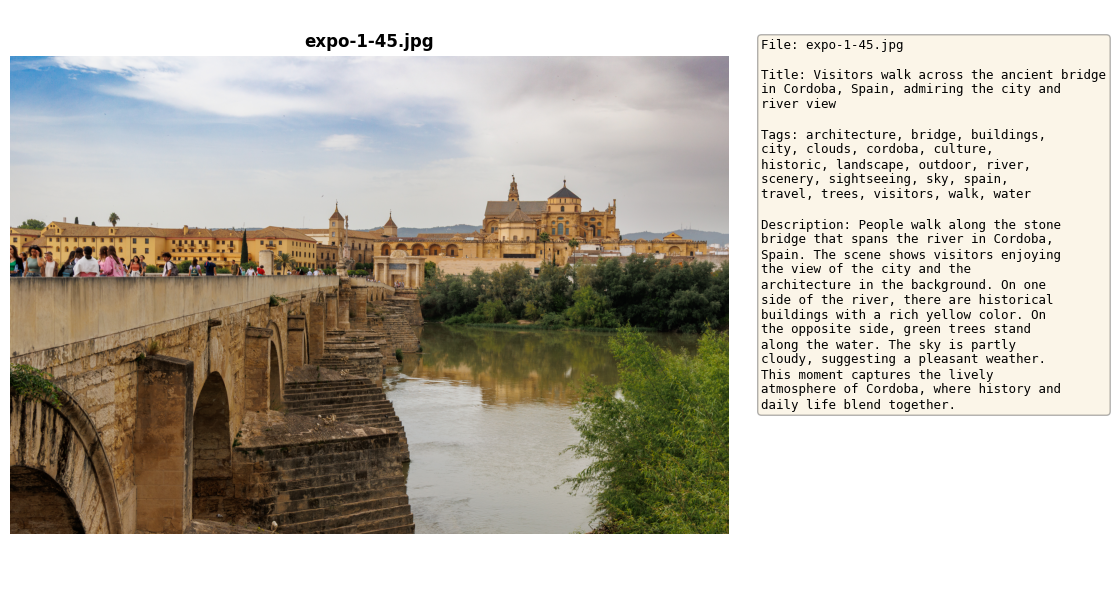

expo-1-45.jpg
Visitors walk across the ancient bridge in Cordoba, Spain, admiring the city and river view
architecture, bridge, buildings, city, clouds, cordoba, culture, historic, landscape, outdoor, river, scenery, sightseeing, sky, spain, travel, trees, visitors, walk, water
People walk along the stone bridge that spans the river in Cordoba, Spain. The scene shows visitors enjoying the view of the city and the architecture in the background. On one side of the river, there are historical buildings with a rich yellow color. On the opposite side, green trees stand along the water. The sky is partly cloudy, suggesting a pleasant weather. This moment captures the lively atmosphere of Cordoba, where history and daily life blend together.



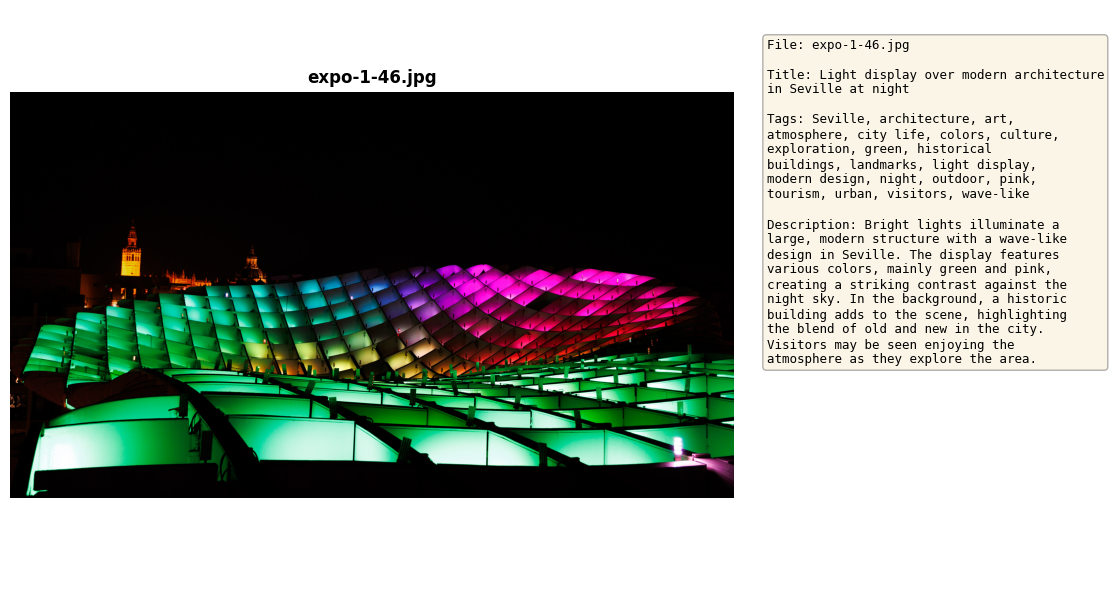

expo-1-46.jpg
Light display over modern architecture in Seville at night
Seville, architecture, art, atmosphere, city life, colors, culture, exploration, green, historical buildings, landmarks, light display, modern design, night, outdoor, pink, tourism, urban, visitors, wave-like
Bright lights illuminate a large, modern structure with a wave-like design in Seville. The display features various colors, mainly green and pink, creating a striking contrast against the night sky. In the background, a historic building adds to the scene, highlighting the blend of old and new in the city. Visitors may be seen enjoying the atmosphere as they explore the area.



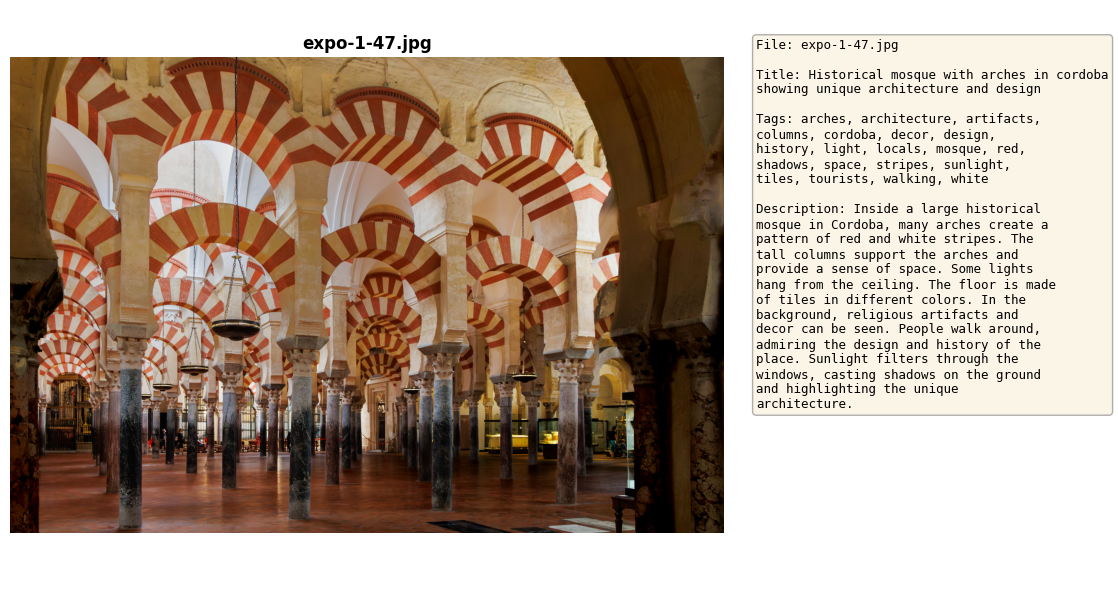

expo-1-47.jpg
Historical mosque with arches in cordoba showing unique architecture and design
arches, architecture, artifacts, columns, cordoba, decor, design, history, light, locals, mosque, red, shadows, space, stripes, sunlight, tiles, tourists, walking, white
Inside a large historical mosque in Cordoba, many arches create a pattern of red and white stripes. The tall columns support the arches and provide a sense of space. Some lights hang from the ceiling. The floor is made of tiles in different colors. In the background, religious artifacts and decor can be seen. People walk around, admiring the design and history of the place. Sunlight filters through the windows, casting shadows on the ground and highlighting the unique architecture.



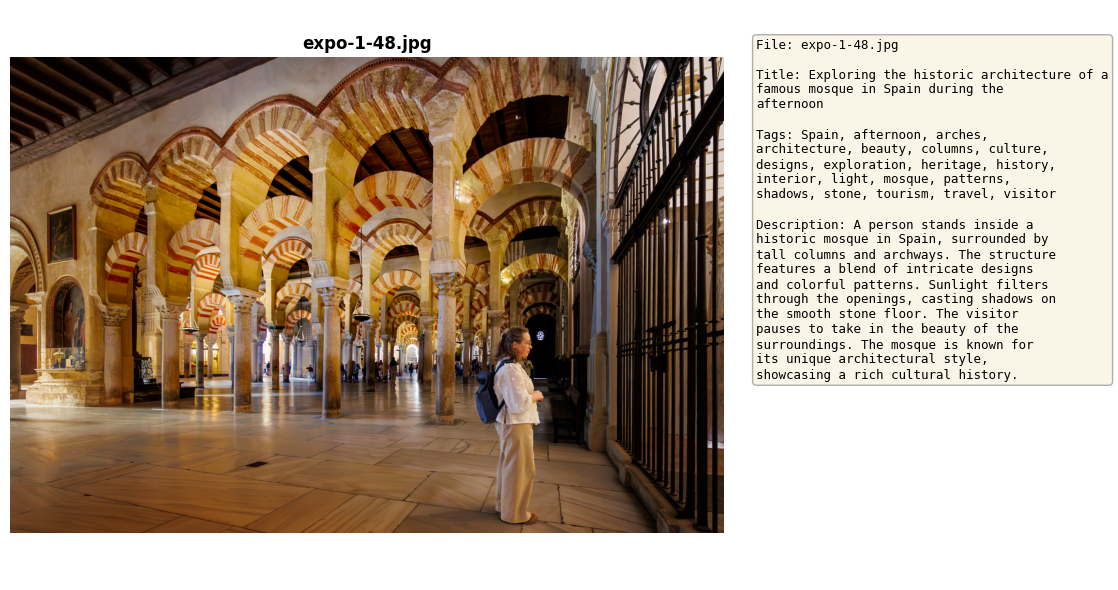

expo-1-48.jpg
Exploring the historic architecture of a famous mosque in Spain during the afternoon
Spain, afternoon, arches, architecture, beauty, columns, culture, designs, exploration, heritage, history, interior, light, mosque, patterns, shadows, stone, tourism, travel, visitor
A person stands inside a historic mosque in Spain, surrounded by tall columns and archways. The structure features a blend of intricate designs and colorful patterns. Sunlight filters through the openings, casting shadows on the smooth stone floor. The visitor pauses to take in the beauty of the surroundings. The mosque is known for its unique architectural style, showcasing a rich cultural history.



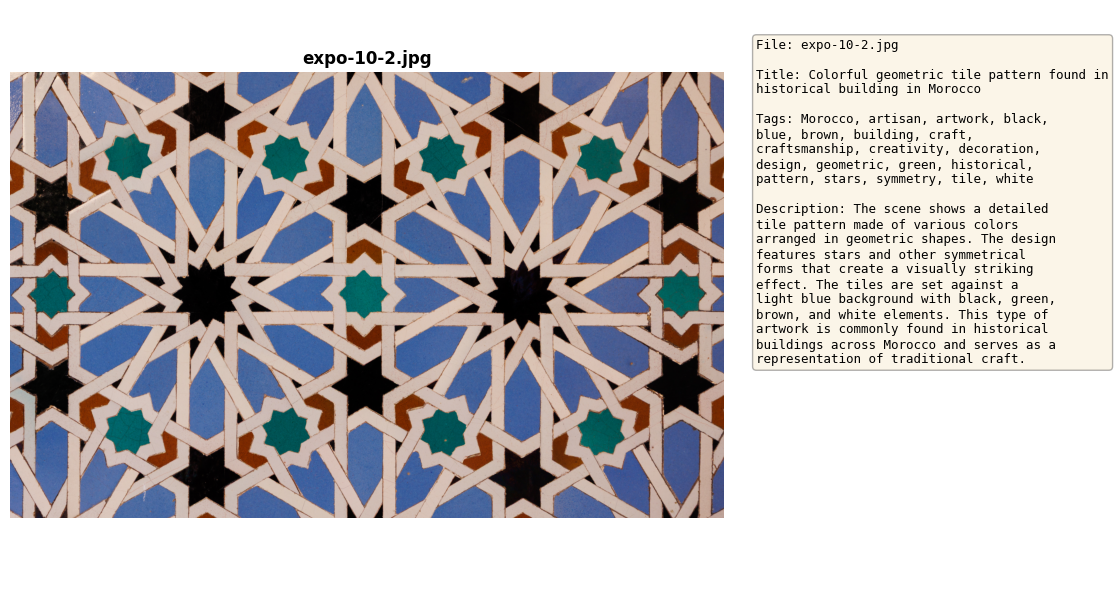

expo-10-2.jpg
Colorful geometric tile pattern found in historical building in Morocco
Morocco, artisan, artwork, black, blue, brown, building, craft, craftsmanship, creativity, decoration, design, geometric, green, historical, pattern, stars, symmetry, tile, white
The scene shows a detailed tile pattern made of various colors arranged in geometric shapes. The design features stars and other symmetrical forms that create a visually striking effect. The tiles are set against a light blue background with black, green, brown, and white elements. This type of artwork is commonly found in historical buildings across Morocco and serves as a representation of traditional craft.



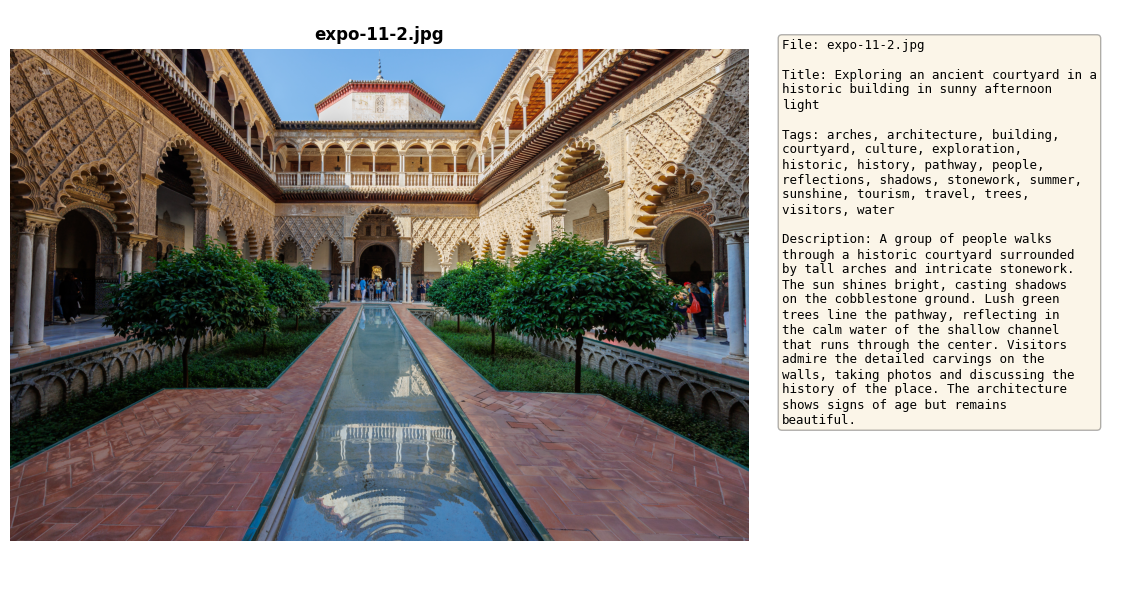

expo-11-2.jpg
Exploring an ancient courtyard in a historic building in sunny afternoon light
arches, architecture, building, courtyard, culture, exploration, historic, history, pathway, people, reflections, shadows, stonework, summer, sunshine, tourism, travel, trees, visitors, water
A group of people walks through a historic courtyard surrounded by tall arches and intricate stonework. The sun shines bright, casting shadows on the cobblestone ground. Lush green trees line the pathway, reflecting in the calm water of the shallow channel that runs through the center. Visitors admire the detailed carvings on the walls, taking photos and discussing the history of the place. The architecture shows signs of age but remains beautiful.



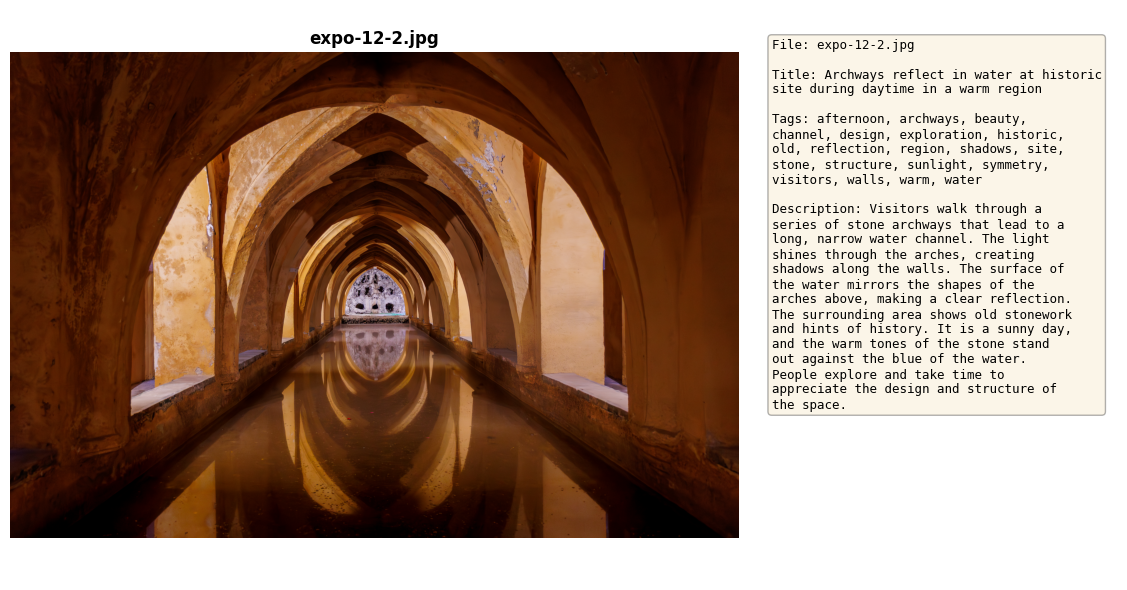

expo-12-2.jpg
Archways reflect in water at historic site during daytime in a warm region
afternoon, archways, beauty, channel, design, exploration, historic, old, reflection, region, shadows, site, stone, structure, sunlight, symmetry, visitors, walls, warm, water
Visitors walk through a series of stone archways that lead to a long, narrow water channel. The light shines through the arches, creating shadows along the walls. The surface of the water mirrors the shapes of the arches above, making a clear reflection. The surrounding area shows old stonework and hints of history. It is a sunny day, and the warm tones of the stone stand out against the blue of the water. People explore and take time to appreciate the design and structure of the space.



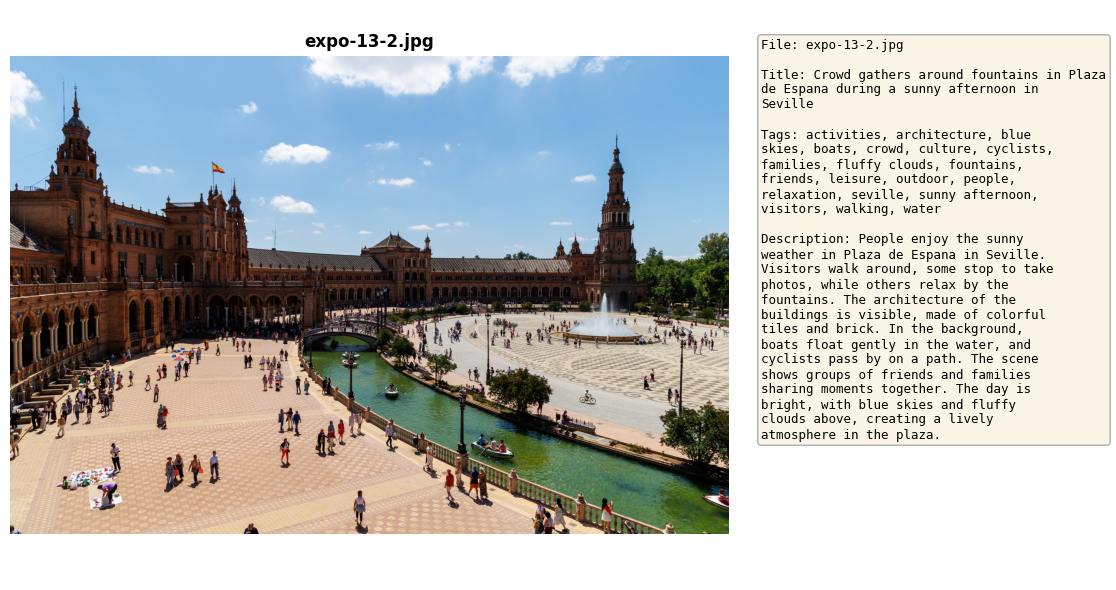

expo-13-2.jpg
Crowd gathers around fountains in Plaza de Espana during a sunny afternoon in Seville
activities, architecture, blue skies, boats, crowd, culture, cyclists, families, fluffy clouds, fountains, friends, leisure, outdoor, people, relaxation, seville, sunny afternoon, visitors, walking, water
People enjoy the sunny weather in Plaza de Espana in Seville. Visitors walk around, some stop to take photos, while others relax by the fountains. The architecture of the buildings is visible, made of colorful tiles and brick. In the background, boats float gently in the water, and cyclists pass by on a path. The scene shows groups of friends and families sharing moments together. The day is bright, with blue skies and fluffy clouds above, creating a lively atmosphere in the plaza.



In [17]:
# Configuration - modify this to change the source folder
SOURCE_FOLDER = (
    Path.home() / "Pictures" / "Lightroom Saved Photos"
)  # Change this to your image folder
MAX_FILE_AGE_DAYS = 10  # Change this value to keep only files newer than N days, or set to None to disable
MAX_FILES=10  # Change this value to limit the number of displayed images, or set to None to disable
REGEXP = "expo-*" # Change this to a regular expression to filter filenames, or set to None to disable

# Supported image extensions
SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".gif", ".bmp", ".webp", ".tiff"}

# Verify the source folder exists
if not SOURCE_FOLDER.exists():
    print(f"Error: Source folder does not exist: {SOURCE_FOLDER}")
else:
    print(f"Source folder: {SOURCE_FOLDER}")

    # Get list of image files
    image_files = []
    for ext in SUPPORTED_EXTENSIONS:
        image_files.extend(SOURCE_FOLDER.glob(f"*{ext}"))
        image_files.extend(SOURCE_FOLDER.glob(f"*{ext.upper()}"))

    image_files = sorted(set(image_files))  # Remove duplicates and sort
    print(f"Found {len(image_files)} image files")

    # Keep only files modified within the last N days
    if MAX_FILE_AGE_DAYS is not None:
        cutoff = datetime.now() - timedelta(days=MAX_FILE_AGE_DAYS)
        image_files = [
            image_path
            for image_path in image_files
            if datetime.fromtimestamp(image_path.stat().st_mtime) >= cutoff
        ]
        print(
            f"Filtered to {len(image_files)} images modified in the last {MAX_FILE_AGE_DAYS} days"
        )

    # Get all filenames stored in the database
    db_records = meta_manager.all()
    db_filenames = {record.filename for record in db_records}
    print(f"Database contains {len(db_filenames)} image filenames")

    # Remove images not present in the database
    image_files = [
        image_path
        for image_path in image_files
        if str(image_path) in db_filenames or image_path.name in db_filenames
    ]
    print(f"Filtered to {len(image_files)} images present in the database")

    # Optional regexp filter on filename
    pattern = re.compile(REGEXP) if REGEXP else None
    if pattern:
        image_files = [
            image_path for image_path in image_files if pattern.search(image_path.name)
        ]
    print(f"Filtered to {len(image_files)} images matching regexp: {REGEXP}")

    if MAX_FILES is not None:
        image_files = image_files[:MAX_FILES]  # Limit to first MAX_FILES images for testing
    print(f"Filtered to {len(image_files)} after limiting to at most {MAX_FILES} images")
    for image_path in image_files:
        display_image_with_metadata(image_path, meta_manager)